In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler

In [2]:
# Question-1 

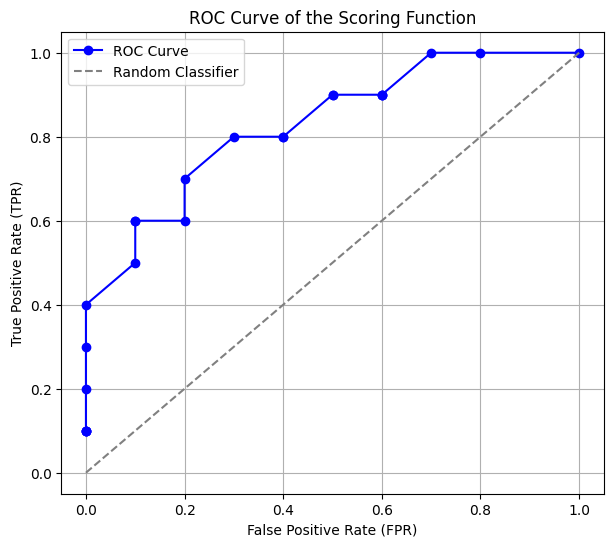

In [3]:
positive_scores = [25, 21, 20, 19, 18, 17, 14, 13, 10, 5]
negative_scores = [18, 15, 13, 12, 10, 8, 5, 4, 3, 3]

thresholds = list(range(3, 26))

total_positives = len(positive_scores)
total_negatives = len(negative_scores)

tpr_values = []
fpr_values = []


for threshold in thresholds:
    TP = sum(score >= threshold for score in positive_scores)  
    FP = sum(score >= threshold for score in negative_scores) 
    FN = total_positives - TP 
    TN = total_negatives - FP 

    TPR = TP / (TP + FN) 
    FPR = FP / (FP + TN) 

    tpr_values.append(TPR)
    fpr_values.append(FPR)

plt.figure(figsize=(7, 6))
plt.plot(fpr_values, tpr_values, marker='o', linestyle='-', color='b', label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve of the Scoring Function")
plt.legend()
plt.grid()

plt.show()

In [4]:
# Question-2

In [5]:
data = np.array([10, 13, 15, 20])

def neg_log_likelihood(theta, data):
    n = len(data)
    constant = -n * np.log(2 * np.sqrt(2 * np.pi))
    sum_squared_diff = np.sum((data - theta)**2)
    return -(constant - (sum_squared_diff / 8))

initial_theta = 0.0

result = minimize(neg_log_likelihood, initial_theta, args=(data,), method='BFGS')

theta_mle = result.x[0]

print(f"Estimated theta (MLE): {theta_mle}")

theta_analytical = np.mean(data)
print(f"Analytical theta (sample mean): {theta_analytical}")

Estimated theta (MLE): 14.499999452345463
Analytical theta (sample mean): 14.5


In [6]:
# Question-3

Logistic Regression Weights:
Intercept (w0): -4.2449
Coefficient (w1): 0.0418


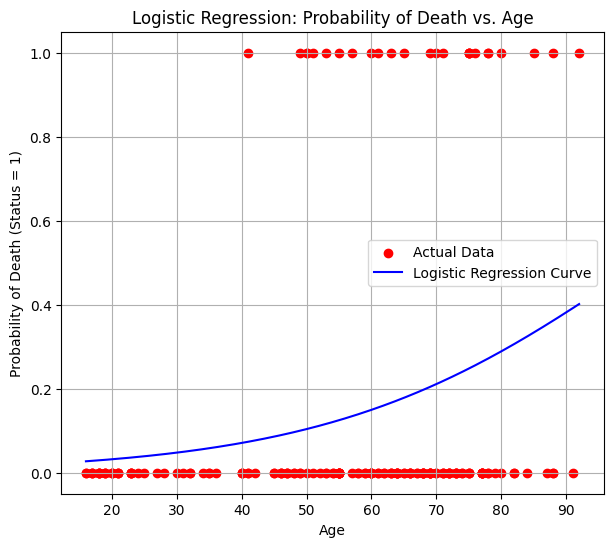

In [7]:
df = pd.read_csv("patient1.csv")

X = df[['age']].values 
y = df['status'].values 

log_reg = LogisticRegression()
log_reg.fit(X, y)

w0 = log_reg.intercept_[0]  
w1 = log_reg.coef_[0][0]  

print(f"Logistic Regression Weights:\nIntercept (w0): {w0:.4f}\nCoefficient (w1): {w1:.4f}")

ages = np.linspace(X.min(), X.max(), 300) 
log_odds = w0 + w1 * ages  
probabilities = 1 / (1 + np.exp(-log_odds)) 

plt.figure(figsize=(7, 6))
plt.scatter(X, y, color='red', label="Actual Data") 
plt.plot(ages, probabilities, color='blue', label="Logistic Regression Curve") 
plt.xlabel("Age")
plt.ylabel("Probability of Death (Status = 1)")
plt.title("Logistic Regression: Probability of Death vs. Age")
plt.legend()
plt.grid()
plt.show()

In [8]:
df = pd.read_excel('Immunotherapy.xlsx')

In [9]:
df.head()

,sex,age,Time,Number_of_Warts,Type,Area,induration_diameter,Result_of_Treatment
0,1,22,2.25,14,3,51,50,1
1,1,15,3.00,2,3,900,70,1
2,1,16,10.50,2,1,100,25,1
3,1,27,4.50,9,3,80,30,1
4,1,20,8.00,6,1,45,8,1


In [10]:
df.columns

Index(['sex', 'age', 'Time', 'Number_of_Warts', 'Type', 'Area',
       'induration_diameter', 'Result_of_Treatment'],
      dtype='object')

In [11]:
# Question-4

In [12]:
file_path = "Immunotherapy.xlsx" 

train_df = pd.read_excel(file_path, sheet_name="Training data set")
test_df = pd.read_excel(file_path, sheet_name="Test data set")

features = ["sex", "age", "Time", "Number_of_Warts", "Type", "Area", "induration_diameter"]
target = "Result_of_Treatment" 

X_train = train_df[features].values
y_train = train_df[target].values

X_test = test_df[features].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

model = Sequential([
    Dense(16, activation='tanh', input_shape=(X_train.shape[1],)), 
    Dense(8, activation='tanh'), 
    Dense(1, activation='sigmoid') 
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print("Predicted Treatment Results for Test Data:")
print(y_pred.flatten())

Epoch 1/50


/Users/prasanthkumar/miniconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3164 - loss: 0.7484  
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 909us/step - accuracy: 0.4259 - loss: 0.7424
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4701 - loss: 0.8057
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.4474 - loss: 0.7362
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.4308 - loss: 0.6590
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.5661 - loss: 0.6265
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step - accuracy: 0.4738 - loss: 0.7054
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6891 - loss: 0.5899
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5647 - loss: 0.6607
Epoch 10/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.5999 - loss: 0.6030
Epoch 11/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.5134 - loss: 0.5869
Epoch 12/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 773us/step - accuracy: 0.53

In [13]:
_, accuracy = model.evaluate(X_train, y_train)
print(f"Training Accuracy: {accuracy:.2f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6078 - loss: 0.3495 
Training Accuracy: 0.57


In [14]:
y_test_actual = test_df[target].values 
print("Actual vs Predicted:", list(zip(y_test_actual, y_pred.flatten())))

Actual vs Predicted: [(np.int64(1), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(-1), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(0)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(0)), (np.int64(-1), np.int64(0)), (np.int64(-1), np.int64(0)), (np.int64(1), np.int64(1))]


In [6]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

In [2]:
df= pd.read_csv('patient1.csv')

In [3]:
df.head()

,status,age
0,0,27
1,0,59
2,0,77
3,0,54
4,0,87


In [19]:
X = df['age'].values.reshape(-1, 1) 
y = df['status'].values

In [20]:
lr = LogisticRegression()

In [21]:
lr.fit(X,y)

LogisticRegression()

In [22]:
lr.coef_

array([[0.04180571]])

In [23]:
lr.intercept_

array([-4.24490936])

In [24]:
df = pd.read_excel('Immunotherapy.xlsx')

In [25]:
df.head()

,sex,age,Time,Number_of_Warts,Type,Area,induration_diameter,Result_of_Treatment
0,1,22,2.25,14,3,51,50,1
1,1,15,3.00,2,3,900,70,1
2,1,16,10.50,2,1,100,25,1
3,1,27,4.50,9,3,80,30,1
4,1,20,8.00,6,1,45,8,1


In [26]:
df.columns

Index(['sex', 'age', 'Time', 'Number_of_Warts', 'Type', 'Area',
       'induration_diameter', 'Result_of_Treatment'],
      dtype='object')